In [2]:
import requests

TOKEN = "8472658545:AAFajo0RO3TIsvTYykQpDlPzk4g5QyGmQD8"
CHAT_ID = "8234161114"

url = f"https://api.telegram.org/bot{TOKEN}/sendMessage"
payload = {"chat_id": CHAT_ID, "text": "🚀 Connection successful! Your bot is ready."}

response = requests.post(url, json=payload)
print("Status Code:", response.status_code)
print("Response:", response.json())

Status Code: 400
Response: {'ok': False, 'error_code': 400, 'description': 'Bad Request: chat not found'}


In [1]:
import tensorflow as tf
import numpy as np

# Set seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Enable Mixed Precision for faster GPU training immediately after imports
tf.keras.mixed_precision.set_global_policy("mixed_float16")

print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [3]:
print(tf.test.is_built_with_cuda())
print(tf.test.gpu_device_name())

True
/device:GPU:0


In [4]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import kagglehub
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [5]:
dataset_path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)
print(dataset_path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia


In [6]:
for root, dirs, files in os.walk(dataset_path):
    print(root)

/kaggle/input/chest-xray-pneumonia
/kaggle/input/chest-xray-pneumonia/chest_xray
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test/PNEUMONIA
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train/PNEUMONIA
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL
/kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX
/kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray
/kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/val
/kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX/chest_x

In [7]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30
train_dir = os.path.join(dataset_path, "chest_xray", "train")
test_dir = os.path.join(dataset_path, "chest_xray", "test")

In [8]:
# train_dir
test_dir

'/kaggle/input/chest-xray-pneumonia/chest_xray/test'

In [9]:
print(os.listdir(train_dir))

['PNEUMONIA', 'NORMAL']


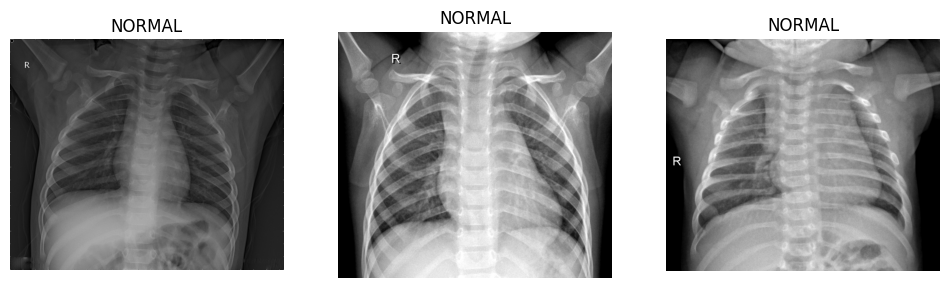

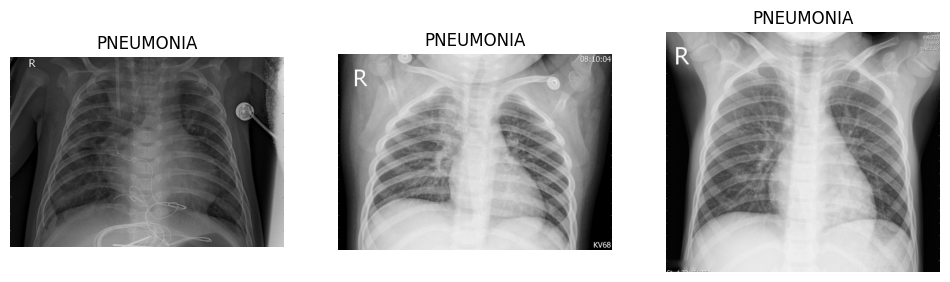

In [10]:
def show_sample_images(folder_path, class_name, n=3):
    class_path = os.path.join(folder_path, class_name)
    images = os.listdir(class_path)[:n]

    plt.figure(figsize=(12, 4))
    for i, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(class_name)
        plt.axis('off')
    plt.show()

show_sample_images(train_dir, "NORMAL")
show_sample_images(train_dir, "PNEUMONIA")

In [11]:
def apply_clahe(img):
    # OpenCV CLAHE expects a uint8 single channel image
    img = np.array(img, dtype=np.uint8)
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    if len(img.shape) == 3 and img.shape[2] == 1:
        img_clahe = clahe.apply(img[:, :, 0])
        img_clahe = np.expand_dims(img_clahe, axis=-1)
    else:
        img_clahe = clahe.apply(img)
    return img_clahe.astype('float32')

train_datagen = ImageDataGenerator(
    preprocessing_function=apply_clahe,
    rescale=1./255,
    rotation_range=5,
    zoom_range=0.05,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=False,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(
    preprocessing_function=apply_clahe,
    rescale=1./255
)

In [12]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [13]:
import json
with open("class_indices.json", "w") as f:
    json.dump(train_data.class_indices, f)
print("Saved class indices:", train_data.class_indices)

Saved class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [14]:
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu', name='last_conv'),
    BatchNormalization(),

    GlobalAveragePooling2D(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(1, activation='sigmoid', dtype='float32')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,785 (1.61 MB)

 Trainable params: 421,825 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [17]:
from tensorflow.keras.callbacks import TensorBoard

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "best_cnn_model.keras",
    monitor='val_loss',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

tensorboard = TensorBoard(log_dir="logs")

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


In [18]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stop, model_checkpoint, reduce_lr, tensorboard],
    class_weight=class_weights
)

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 152s 926ms/step - accuracy: 0.8773 - auc: 0.9513 - loss: 0.4137 - precision: 0.9716 - recall: 0.8600 - val_accuracy: 0.7430 - val_auc: 0.5000 - val_loss: 3.0229 - val_precision: 0.7430 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 444ms/step - accuracy: 0.9137 - auc: 0.9736 - loss: 0.3037 - precision: 0.9787 - recall: 0.9035 - val_accuracy: 0.7430 - val_auc: 0.5000 - val_loss: 2.2025 - val_precision: 0.7430 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 59s 450ms/step - accuracy: 0.9336 - auc: 0.9816 - loss: 0.2398 - precision: 0.9829 - recall: 0.9268 - val_accuracy: 0.7430 - val_auc: 0.5000 - val_loss: 2.7498 - val_precision: 0.7430 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 59s 449ms/step - accuracy: 0.9310 - auc: 0.9837 - loss: 0.2170 - precision: 0.9789 - recall: 0.9271 - val_accuracy: 0.7430 - val_auc: 0.5000 - val_loss:

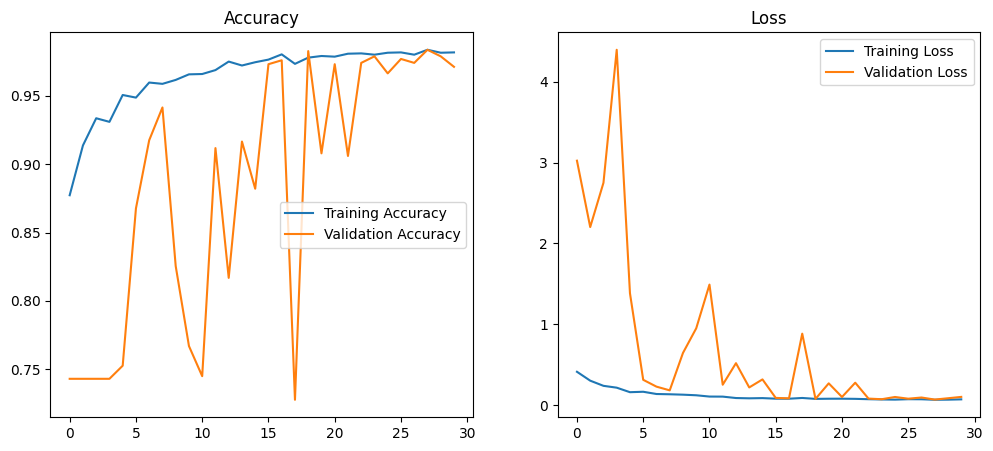

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [20]:
test_metrics = model.evaluate(test_data)
print("Test Loss:", test_metrics[0])
print("Test Accuracy:", test_metrics[1])
print("Test Precision:", test_metrics[2])
print("Test Recall:", test_metrics[3])
print("Test AUC:", test_metrics[4])

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 392ms/step - accuracy: 0.8766 - auc: 0.9713 - loss: 0.3519 - precision: 0.9815 - recall: 0.8179
Test Loss: 0.3519320785999298
Test Accuracy: 0.8766025900840759
Test Precision: 0.9815384745597839
Test Recall: 0.8179486989974976
Test AUC: 0.9713181853294373


In [21]:
y_prob = model.predict(test_data)
y_true = test_data.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 191ms/step


Optimal Threshold from ROC: 0.0666
Confusion Matrix:
 [[204  30]
 [ 17 373]]

Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.92      0.87      0.90       234
   PNEUMONIA       0.93      0.96      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.91      0.92       624
weighted avg       0.92      0.92      0.92       624

Sensitivity (Recall): 0.9564
Specificity: 0.8718
F1 Score: 0.9407


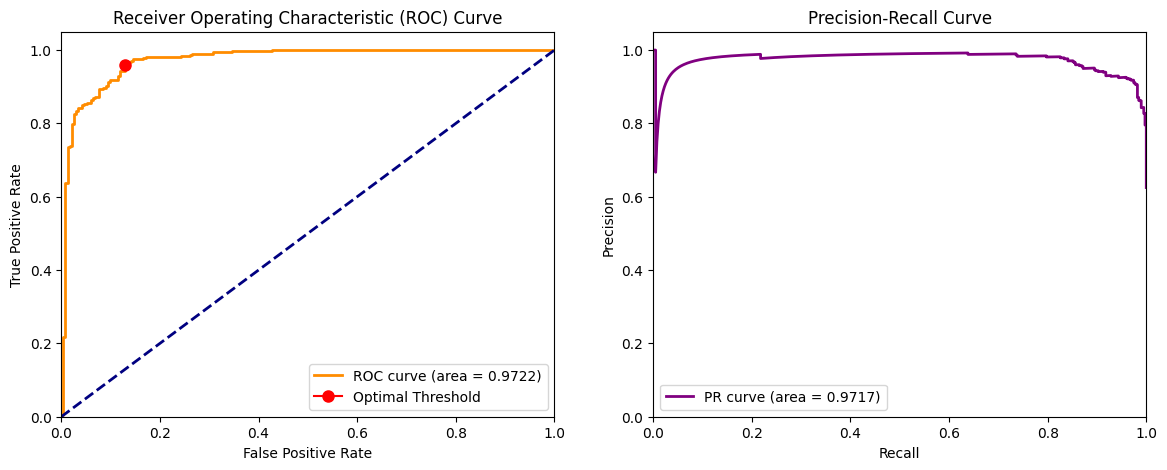

In [22]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score
import seaborn as sns

# Calculate optimal threshold using Youden's J statistic
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold from ROC: {optimal_threshold:.4f}")

# Apply optimal threshold
y_pred = (y_prob > optimal_threshold).astype(int).reshape(-1)

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

# Sensitivity (Recall) and Specificity
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")

# Plot ROC and PR Curves
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_true, y_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(14, 5))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot(fpr[optimal_idx], tpr[optimal_idx], marker='o', markersize=8, color="red", label="Optimal Threshold")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='purple', lw=2, label=f'PR curve (area = {pr_auc:.4f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")

plt.show()

In [23]:
model.save("best_cnn_model.keras") # Changed to .tf extension
print("Model saved successfully.")

Model saved successfully.


In [24]:
loaded_model = tf.keras.models.load_model("best_cnn_model.keras")

In [25]:
def predict_single_image(img_path, model, threshold=0.5):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=-1)      # (224, 224, 1)
    img = np.expand_dims(img, axis=0)       # (1, 224, 224, 1)

    prob = model.predict(img)[0][0]
    label = "PNEUMONIA" if prob > threshold else "NORMAL"
    confidence = prob if prob > threshold else 1 - prob

    return label, confidence

# Get a sample image path from the test directory
sample_normal_image_path = os.path.join(test_dir, "NORMAL", os.listdir(os.path.join(test_dir, "NORMAL"))[0])

label, confidence = predict_single_image(sample_normal_image_path, loaded_model, threshold=optimal_threshold)
print("Prediction:", label)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: PNEUMONIA
Confidence: 0.9885473


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 1))
  warnings.warn(msg)
/tmp/ipykernel_3116/3994791788.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


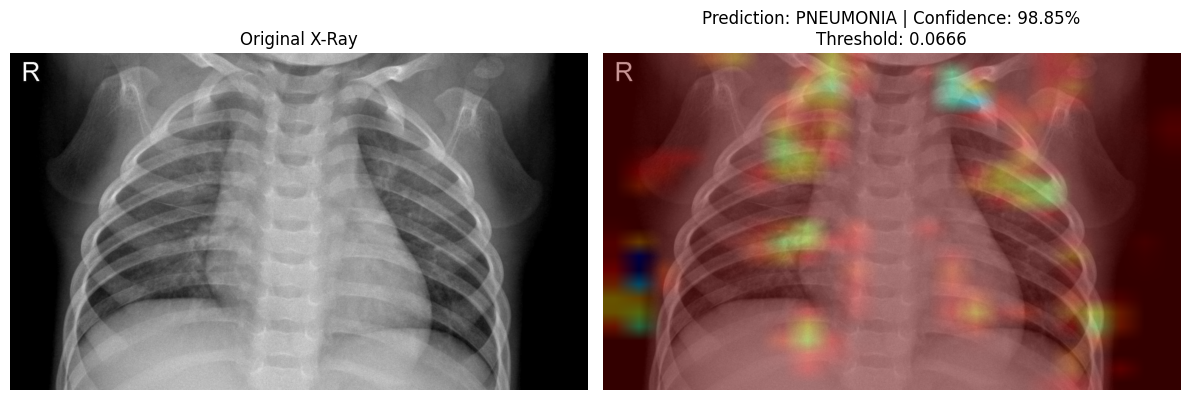

In [35]:
import matplotlib.cm as cm

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="last_conv"):
    # 1. Create a model that outputs the last conv layer activations and the final predictions
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Compute the gradient of the top predicted class for the input image
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        # For binary classification (1 neuron), we track the score of that neuron
        # If it's multi-class, you'd use preds[:, pred_index]
        class_channel = preds[:, 0]

    # 3. Gradient of the output neuron w.r.t. the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 4. Vector of mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Multiply each channel in the feature map by 'how important it is'
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. Normalize the heatmap between 0 & 1 for visualization
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def show_prediction_with_gradcam(img_path, model, last_conv_layer_name="last_conv", threshold=0.5):
    label, confidence = predict_single_image(img_path, model, threshold=threshold)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    img_array = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_array = img_array.astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=-1)
    img_array = np.expand_dims(img_array, axis=0)

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))
    jet_heatmap = np.uint8(255 * jet_heatmap)

    superimposed_img = cv2.addWeighted(img_color, 0.6, jet_heatmap, 0.4, 0)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Original X-Ray")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Prediction: {label} | Conf: {confidence*100:.2f}%\nThreshold: {threshold:.4f}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [48]:
# --- Preprocessing for Pretrained Models (DenseNet121 & EfficientNetB0) ---

def clahe_rgb_preprocess(img, preprocess_func):
    """Applies CLAHE, converts to RGB (3 channels), and applies model-specific preprocessing."""
    img = np.array(img, dtype=np.uint8)
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))

    # Apply CLAHE depending on input shape
    if len(img.shape) == 3 and img.shape[2] == 1:
        img_clahe = clahe.apply(img[:, :, 0])
    elif len(img.shape) == 2:
        img_clahe = clahe.apply(img)
    else:
        # If already 3 channels, convert to gray for CLAHE
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img_clahe = clahe.apply(img_gray)

    # Convert back to 3 channels for DenseNet/EfficientNet
    img_rgb = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)

    # Convert to float and apply specific preprocess_input
    img_rgb = img_rgb.astype('float32')
    return preprocess_func(img_rgb)

def clahe_preprocess_densenet(img):
    return clahe_rgb_preprocess(img, tf.keras.applications.densenet.preprocess_input)

def clahe_preprocess_efficientnet(img):
    return clahe_rgb_preprocess(img, tf.keras.applications.efficientnet.preprocess_input)

In [37]:
# --- DenseNet121: Data Generators ---
densenet_train_datagen = ImageDataGenerator(
    preprocessing_function=clahe_preprocess_densenet,
    rotation_range=5,
    zoom_range=0.05,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=False,
    validation_split=0.2
)
densenet_test_datagen = ImageDataGenerator(
    preprocessing_function=clahe_preprocess_densenet
)

densenet_train_data = densenet_train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE), color_mode="rgb",
    batch_size=BATCH_SIZE, class_mode="binary", subset="training", shuffle=True
)
densenet_val_data = densenet_train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE), color_mode="rgb",
    batch_size=BATCH_SIZE, class_mode="binary", subset="validation", shuffle=False
)
densenet_test_data = densenet_test_datagen.flow_from_directory(
    test_dir, target_size=(IMG_SIZE, IMG_SIZE), color_mode="rgb",
    batch_size=BATCH_SIZE, class_mode="binary", shuffle=False
)

# --- DenseNet121: Architecture ---
densenet_base = tf.keras.applications.DenseNet121(
    include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
densenet_base.trainable = False

densenet_model = Sequential([
    densenet_base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(1, activation='sigmoid', dtype='float32')
])

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [38]:
# --- DenseNet121: Phase A (Train Head) ---
print("--- DenseNet121: Phase A ---")
densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=["accuracy", tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)

densenet_checkpoint = ModelCheckpoint("best_densenet_model.keras", monitor='val_loss', save_best_only=True)

history_densenet_a = densenet_model.fit(
    densenet_train_data, validation_data=densenet_val_data, epochs=5,
    callbacks=[early_stop, densenet_checkpoint, reduce_lr, tensorboard],
    class_weight=class_weights
)

# --- DenseNet121: Phase B (Fine-Tune) ---
print("--- DenseNet121: Phase B ---")
densenet_base.trainable = True
for layer in densenet_base.layers[:-30]:  # Unfreeze last 30 layers
    layer.trainable = False

densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=["accuracy", tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)

history_densenet_b = densenet_model.fit(
    densenet_train_data, validation_data=densenet_val_data, epochs=5,
    callbacks=[early_stop, densenet_checkpoint, reduce_lr, tensorboard],
    class_weight=class_weights
)

--- DenseNet121: Phase A ---
Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.9099 - auc: 0.9735 - loss: 0.3460 - precision: 0.9766 - recall: 0.9003 - val_accuracy: 0.9616 - val_auc: 0.9930 - val_loss: 0.2191 - val_precision: 0.9829 - val_recall: 0.9652 - learning_rate: 0.0010
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 111s 846ms/step - accuracy: 0.9375 - auc: 0.9854 - loss: 0.2541 - precision: 0.9840 - recall: 0.9310 - val_accuracy: 0.9674 - val_auc: 0.9947 - val_loss: 0.1798 - val_precision: 0.9831 - val_recall: 0.9729 - learning_rate: 0.0010
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 110s 843ms/step - accuracy: 0.9557 - auc: 0.9918 - loss: 0.2014 - precision: 0.9889 - recall: 0.9510 - val_accuracy: 0.9559 - val_auc: 0.9970 - val_loss: 0.1862 - val_precision: 1.0000 - val_recall: 0.9406 - learning_rate: 5.0000e-04
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 111s 849ms/step - accuracy: 0.9571 - auc: 0.9928 - loss: 0.1833 - precision: 0.9880 - recall: 0.9539 - val_accuracy: 0.9626 

In [39]:
# --- Evaluate DenseNet121 ---
best_densenet = tf.keras.models.load_model("best_densenet_model.keras")
densenet_prob = best_densenet.predict(densenet_test_data)

fpr_dn, tpr_dn, thresholds_dn = roc_curve(y_true, densenet_prob)
optimal_idx_dn = np.argmax(tpr_dn - fpr_dn)
optimal_threshold_dn = thresholds_dn[optimal_idx_dn]

densenet_pred = (densenet_prob > optimal_threshold_dn).astype(int).reshape(-1)

print(f"DenseNet121 Optimal Threshold: {optimal_threshold_dn:.4f}")
print("DenseNet121 Classification Report:")
print(classification_report(y_true, densenet_pred, target_names=['NORMAL', 'PNEUMONIA']))
print(f"DenseNet121 F1 Score: {f1_score(y_true, densenet_pred):.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step
DenseNet121 Optimal Threshold: 0.9503
DenseNet121 Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.85      0.95      0.90       234
   PNEUMONIA       0.97      0.90      0.93       390

    accuracy                           0.92       624
   macro avg       0.91      0.92      0.91       624
weighted avg       0.92      0.92      0.92       624

DenseNet121 F1 Score: 0.9323


In [40]:
# --- EfficientNetB0: Data Generators ---
effnet_train_datagen = ImageDataGenerator(
    preprocessing_function=clahe_preprocess_efficientnet,
    rotation_range=5,
    zoom_range=0.05,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=False,
    validation_split=0.2
)
effnet_test_datagen = ImageDataGenerator(
    preprocessing_function=clahe_preprocess_efficientnet
)

effnet_train_data = effnet_train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE), color_mode="rgb",
    batch_size=BATCH_SIZE, class_mode="binary", subset="training", shuffle=True
)
effnet_val_data = effnet_train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE), color_mode="rgb",
    batch_size=BATCH_SIZE, class_mode="binary", subset="validation", shuffle=False
)
effnet_test_data = effnet_test_datagen.flow_from_directory(
    test_dir, target_size=(IMG_SIZE, IMG_SIZE), color_mode="rgb",
    batch_size=BATCH_SIZE, class_mode="binary", shuffle=False
)

# --- EfficientNetB0: Architecture ---
effnet_base = tf.keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
effnet_base.trainable = False

effnet_model = Sequential([
    effnet_base,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid', dtype='float32')
])

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [41]:
# --- EfficientNetB0: Phase A (Train Head) ---
print("--- EfficientNetB0: Phase A ---")
effnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=["accuracy", tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)

effnet_checkpoint = ModelCheckpoint("best_efficientnet_model.keras", monitor='val_loss', save_best_only=True)

history_effnet_a = effnet_model.fit(
    effnet_train_data, validation_data=effnet_val_data, epochs=5,
    callbacks=[early_stop, effnet_checkpoint, reduce_lr, tensorboard],
    class_weight=class_weights
)

# --- EfficientNetB0: Phase B (Fine-Tune) ---
print("--- EfficientNetB0: Phase B ---")
effnet_base.trainable = True
for layer in effnet_base.layers[:-20]:  # Unfreeze last 20 layers
    layer.trainable = False

effnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=["accuracy", tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)

history_effnet_b = effnet_model.fit(
    effnet_train_data, validation_data=effnet_val_data, epochs=5,
    callbacks=[early_stop, effnet_checkpoint, reduce_lr, tensorboard],
    class_weight=class_weights
)

--- EfficientNetB0: Phase A ---
Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.8780 - auc: 0.9706 - loss: 0.2442 - precision: 0.9858 - recall: 0.8481 - val_accuracy: 0.9530 - val_auc: 0.9910 - val_loss: 0.1433 - val_precision: 0.9630 - val_recall: 0.9742 - learning_rate: 0.0010
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 815ms/step - accuracy: 0.9288 - auc: 0.9817 - loss: 0.1727 - precision: 0.9811 - recall: 0.9219 - val_accuracy: 0.9377 - val_auc: 0.9937 - val_loss: 0.1460 - val_precision: 0.9986 - val_recall: 0.9174 - learning_rate: 0.0010
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 832ms/step - accuracy: 0.9425 - auc: 0.9882 - loss: 0.1359 - precision: 0.9884 - recall: 0.9335 - val_accuracy: 0.9511 - val_auc: 0.9950 - val_loss: 0.1240 - val_precision: 0.9945 - val_recall: 0.9394 - learning_rate: 5.0000e-04
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 106s 814ms/step - accuracy: 0.9497 - auc: 0.9897 - loss: 0.1236 - precision: 0.9875 - recall: 0.9442 - val_accuracy: 0.91

In [42]:
# --- Evaluate EfficientNetB0 ---
best_effnet = tf.keras.models.load_model("best_efficientnet_model.keras")
effnet_prob = best_effnet.predict(effnet_test_data)

fpr_ef, tpr_ef, thresholds_ef = roc_curve(y_true, effnet_prob)
optimal_idx_ef = np.argmax(tpr_ef - fpr_ef)
optimal_threshold_ef = thresholds_ef[optimal_idx_ef]

effnet_pred = (effnet_prob > optimal_threshold_ef).astype(int).reshape(-1)

print(f"EfficientNetB0 Optimal Threshold: {optimal_threshold_ef:.4f}")
print("EfficientNetB0 Classification Report:")
print(classification_report(y_true, effnet_pred, target_names=['NORMAL', 'PNEUMONIA']))
print(f"EfficientNetB0 F1 Score: {f1_score(y_true, effnet_pred):.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step
EfficientNetB0 Optimal Threshold: 0.8754
EfficientNetB0 Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.87      0.89      0.88       234
   PNEUMONIA       0.93      0.92      0.93       390

    accuracy                           0.91       624
   macro avg       0.90      0.90      0.90       624
weighted avg       0.91      0.91      0.91       624

EfficientNetB0 F1 Score: 0.9251


--- Evaluating Weighted Ensemble ---
Ensemble Optimal Threshold: 0.9018
Ensemble Confusion Matrix:
 [[222  12]
 [ 38 352]]

Ensemble Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.85      0.95      0.90       234
   PNEUMONIA       0.97      0.90      0.93       390

    accuracy                           0.92       624
   macro avg       0.91      0.93      0.92       624
weighted avg       0.92      0.92      0.92       624

Ensemble Sensitivity (Recall): 0.9026
Ensemble Specificity: 0.9487
Ensemble F1 Score: 0.9337


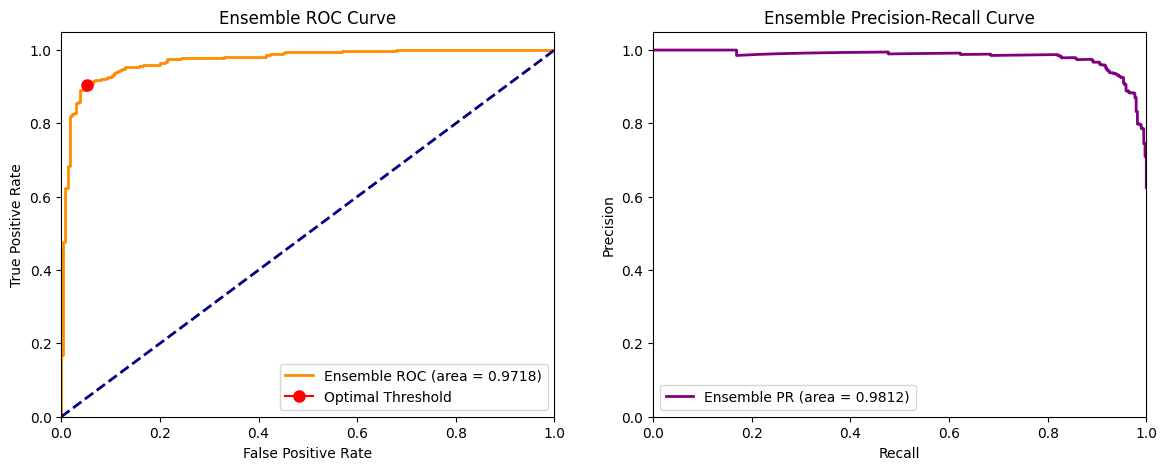

In [43]:
# --- Weighted Ensemble ---
print("--- Evaluating Weighted Ensemble ---")

# We already have densenet_prob and effnet_prob from evaluating both models
ensemble_prob = 0.6 * densenet_prob + 0.4 * effnet_prob

# Calculate Optimal Threshold for Ensemble
fpr_ens, tpr_ens, thresholds_ens = roc_curve(y_true, ensemble_prob)
optimal_idx_ens = np.argmax(tpr_ens - fpr_ens)
optimal_threshold_ens = thresholds_ens[optimal_idx_ens]

ensemble_pred = (ensemble_prob > optimal_threshold_ens).astype(int).reshape(-1)

print(f"Ensemble Optimal Threshold: {optimal_threshold_ens:.4f}")

# Calculate confusion matrix
cm_ens = confusion_matrix(y_true, ensemble_pred)
print("Ensemble Confusion Matrix:\n", cm_ens)
print("\nEnsemble Classification Report:\n", classification_report(y_true, ensemble_pred, target_names=['NORMAL', 'PNEUMONIA']))

# Sensitivity (Recall) and Specificity
tn_ens, fp_ens, fn_ens, tp_ens = cm_ens.ravel()
sensitivity_ens = tp_ens / (tp_ens + fn_ens)
specificity_ens = tn_ens / (tn_ens + fp_ens)
print(f"Ensemble Sensitivity (Recall): {sensitivity_ens:.4f}")
print(f"Ensemble Specificity: {specificity_ens:.4f}")
print(f"Ensemble F1 Score: {f1_score(y_true, ensemble_pred):.4f}")

# Plot ROC and PR Curves for Ensemble
roc_auc_ens = auc(fpr_ens, tpr_ens)
precision_ens, recall_ens, _ = precision_recall_curve(y_true, ensemble_prob)
pr_auc_ens = auc(recall_ens, precision_ens)

plt.figure(figsize=(14, 5))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr_ens, tpr_ens, color='darkorange', lw=2, label=f'Ensemble ROC (area = {roc_auc_ens:.4f})')
plt.plot(fpr_ens[optimal_idx_ens], tpr_ens[optimal_idx_ens], marker='o', markersize=8, color="red", label="Optimal Threshold")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble ROC Curve')
plt.legend(loc="lower right")

# Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall_ens, precision_ens, color='purple', lw=2, label=f'Ensemble PR (area = {pr_auc_ens:.4f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Ensemble Precision-Recall Curve')
plt.legend(loc="lower left")

plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_4']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


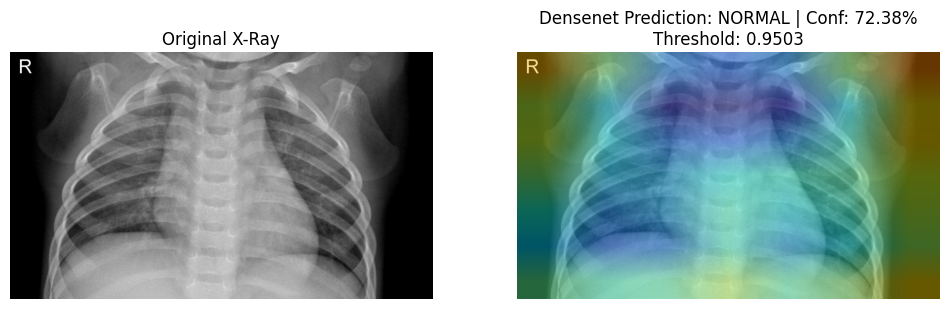

In [55]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import cv2
import tensorflow as tf

def get_gradcam_model_details(model_name):
    if model_name == "densenet":
        # Access the base model (index 0 in Sequential) to ensure functional connectivity
        return best_densenet.layers[0], "conv5_block16_concat", clahe_preprocess_densenet, float(np.array(optimal_threshold_dn).flatten()[0])
    elif model_name == "efficientnet":
        return best_effnet.layers[0], "top_activation", clahe_preprocess_efficientnet, float(np.array(optimal_threshold_ef).flatten()[0])
    else: # default to scratch cnn
        return loaded_model, "last_conv", lambda x: x, float(np.array(optimal_threshold).flatten()[0])

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Recursive search for the layer
    def find_layer(m, name):
        try:
            return m.get_layer(name)
        except ValueError:
            if hasattr(m, 'layers'):
                for l in m.layers:
                    res = find_layer(l, name)
                    if res: return res
        return None

    target_layer = find_layer(model, last_conv_layer_name)
    if not target_layer:
        raise ValueError(f"Could not find layer {last_conv_layer_name}")

    # Build the gradient model using the model's own inputs/outputs
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[target_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        # For base models, preds might be feature maps, so we reduce to global average if needed,
        # but here we target the class prediction. Note: If using base model, we use the first channel of its output
        class_channel = tf.reduce_mean(preds, axis=-1)

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def show_ensemble_gradcam(img_path, model_name="densenet"):
    # Get full sequential model for prediction, but base model for Grad-CAM
    if model_name == "densenet":
        full_model, base_model, last_conv_name, preprocess_func, threshold = best_densenet, best_densenet.layers[0], "conv5_block16_concat", clahe_preprocess_densenet, float(np.array(optimal_threshold_dn).flatten()[0])
    elif model_name == "efficientnet":
        full_model, base_model, last_conv_name, preprocess_func, threshold = best_effnet, best_effnet.layers[0], "top_activation", clahe_preprocess_efficientnet, float(np.array(optimal_threshold_ef).flatten()[0])
    else:
        full_model, base_model, last_conv_name, preprocess_func, threshold = loaded_model, loaded_model, "last_conv", lambda x: x, float(np.array(optimal_threshold).flatten()[0])

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    if model_name in ["densenet", "efficientnet"]:
        img_array_base = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img_array_preprocessed = preprocess_func(img_array_base)
        img_array = np.expand_dims(img_array_preprocessed, axis=0)
    else:
        img_array = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img_array = img_array.astype("float32") / 255.0
        img_array = np.expand_dims(img_array, axis=-1)
        img_array = np.expand_dims(img_array, axis=0)

    preds = full_model.predict(img_array, verbose=0)
    prob = float(preds.flatten()[0])
    label = "PNEUMONIA" if prob > threshold else "NORMAL"
    confidence = prob if prob > threshold else 1.0 - prob

    # Generate heatmap using the base model to avoid Sequential output errors
    heatmap = make_gradcam_heatmap(img_array, base_model, last_conv_name)

    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))
    jet_heatmap = np.uint8(255 * jet_heatmap)

    superimposed_img = cv2.addWeighted(img_color, 0.6, jet_heatmap, 0.4, 0)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original X-Ray")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title(f"{model_name.capitalize()} Prediction: {label} | Conf: {confidence*100:.2f}%\nThreshold: {threshold:.4f}")
    plt.axis('off')
    plt.show()

show_ensemble_gradcam(sample_normal_image_path, model_name="densenet")

In [56]:
import json
ensemble_config = {
    "weights": [0.6, 0.4],
    "threshold": float(optimal_threshold_ens),
    "version": "v1.0"
}
with open("ensemble_config.json", "w") as f:
    json.dump(ensemble_config, f)
print("Saved ensemble configuration to ensemble_config.json")

Saved ensemble configuration to ensemble_config.json


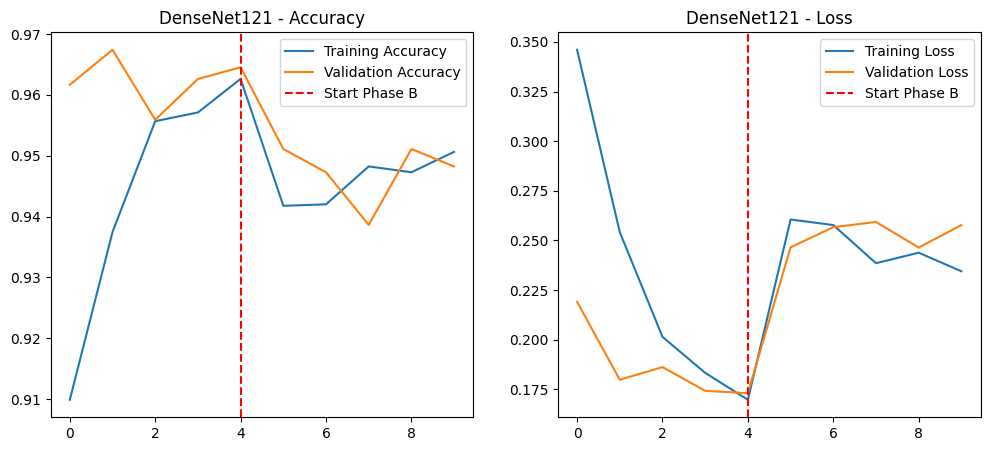

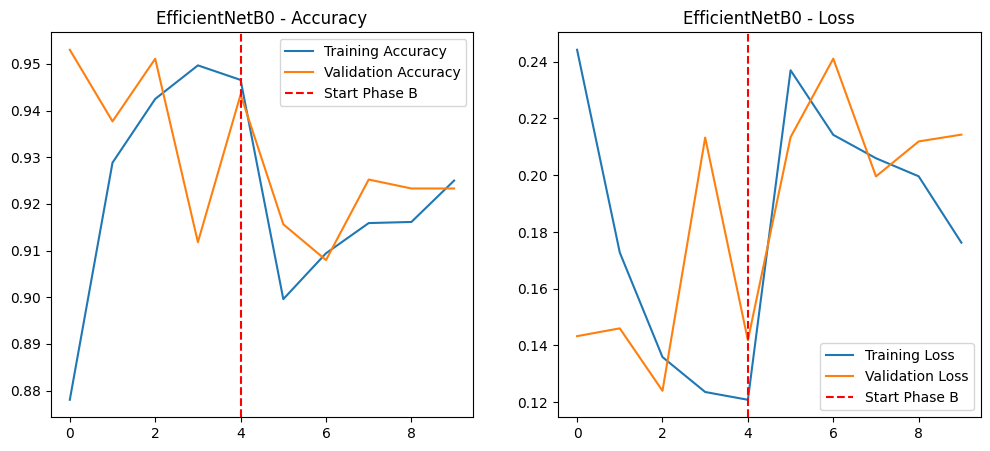

In [57]:
def plot_two_phase_history(history_a, history_b, title):
    acc = history_a.history['accuracy'] + history_b.history['accuracy']
    val_acc = history_a.history['val_accuracy'] + history_b.history['val_accuracy']
    loss = history_a.history['loss'] + history_b.history['loss']
    val_loss = history_a.history['val_loss'] + history_b.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.axvline(x=len(history_a.history['accuracy'])-1, color='r', linestyle='--', label='Start Phase B')
    plt.legend()
    plt.title(f'{title} - Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.axvline(x=len(history_a.history['loss'])-1, color='r', linestyle='--', label='Start Phase B')
    plt.legend()
    plt.title(f'{title} - Loss')
    plt.show()

# Plot histories for both models
plot_two_phase_history(history_densenet_a, history_densenet_b, "DenseNet121")
plot_two_phase_history(history_effnet_a, history_effnet_b, "EfficientNetB0")

In [59]:
import time
import pandas as pd
from sklearn.metrics import accuracy_score,roc_auc_score

# Latency Measurement Helper
def measure_latency(model, img_array):
    start = time.perf_counter()
    model.predict(img_array, verbose=0)
    end = time.perf_counter()
    return (end - start) * 1000  # in ms

# Prepare sample image for each model
sample_scratch = np.expand_dims(np.expand_dims(cv2.resize(cv2.imread(sample_normal_image_path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE)).astype("float32")/255.0, -1), 0)
sample_pre = cv2.resize(cv2.imread(sample_normal_image_path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE))
sample_dn = np.expand_dims(clahe_preprocess_densenet(sample_pre), 0)
sample_ef = np.expand_dims(clahe_preprocess_efficientnet(sample_pre), 0)

# Measure Latencies
latency_scratch = measure_latency(loaded_model, sample_scratch)
latency_dn = measure_latency(best_densenet, sample_dn)
latency_ef = measure_latency(best_effnet, sample_ef)

# Measure Ensemble Latency directly
start = time.perf_counter()
p_dn = best_densenet.predict(sample_dn, verbose=0)
p_ef = best_effnet.predict(sample_ef, verbose=0)
_ = 0.6 * p_dn + 0.4 * p_ef
end = time.perf_counter()
latency_ens = (end - start) * 1000

# Helper to calculate evaluation metrics
def get_metrics(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y_true, y_pred)
    prec = tp / (tp + fp) if (tp+fp) > 0 else 0
    rec = tp / (tp + fn) if (tp+fn) > 0 else 0
    f1 = f1_score(y_true, y_pred)
    spec = tn / (tn + fp) if (tn+fp) > 0 else 0
    auc_score = roc_auc_score(y_true, y_prob)
    return [f"{acc:.4f}", f"{prec:.4f}", f"{rec:.4f}", f"{f1:.4f}", f"{spec:.4f}", f"{auc_score:.4f}"]

# Define predictions based on optimal thresholds
y_pred_scratch = (y_prob > optimal_threshold).astype(int).reshape(-1)
y_pred_dn = (densenet_prob > optimal_threshold_dn).astype(int).reshape(-1)
y_pred_ef = (effnet_prob > optimal_threshold_ef).astype(int).reshape(-1)
y_pred_ens = (ensemble_prob > optimal_threshold_ens).astype(int).reshape(-1)

# Generate Comparison Table
data = [
    ["Scratch CNN"] + get_metrics(y_true, y_pred_scratch, y_prob) + [f"{latency_scratch:.2f} ms"],
    ["DenseNet121"] + get_metrics(y_true, y_pred_dn, densenet_prob) + [f"{latency_dn:.2f} ms"],
    ["EfficientNetB0"] + get_metrics(y_true, y_pred_ef, effnet_prob) + [f"{latency_ef:.2f} ms"],
    ["Ensemble"] + get_metrics(y_true, y_pred_ens, ensemble_prob) + [f"{latency_ens:.2f} ms"]
]

df = pd.DataFrame(data, columns=["Model", "Accuracy", "Precision", "Recall (Sens)", "F1", "Specificity", "AUC", "Latency"])
display(df)

,Model,Accuracy,Precision,Recall (Sens),F1,Specificity,AUC,Latency
0,Scratch CNN,0.9247,0.9256,0.9564,0.9407,0.8718,0.9722,203.14 ms
1,DenseNet121,0.9183,0.9669,0.9000,0.9323,0.9487,0.9721,323.99 ms
2,EfficientNetB0,0.9071,0.9323,0.9179,0.9251,0.8889,0.9584,335.54 ms
3,Ensemble,0.9199,0.9670,0.9026,0.9337,0.9487,0.9718,915.89 ms


## ⚙️ Centralized Configuration
All hyper-parameters and paths live here; edit once, run everywhere.


In [ ]:
# ════════════════════════════════════════════════════════════
# SECTION 0 – CENTRALIZED CONFIGURATION
# ════════════════════════════════════════════════════════════
import os

CONFIG = {
    # Dataset
    'IMG_SIZE'       : 224,
    'BATCH_SIZE'     : 32,
    'EPOCHS'         : 30,
    # Ensemble weights (DenseNet, EfficientNet)
    'ENS_W_DN'       : 0.60,
    'ENS_W_EF'       : 0.40,
    # Paths — set dataset_path before running
    'DATASET_PATH'   : None,          # filled after kagglehub download
    # Bootstrap
    'BOOTSTRAP_ITERS': 1000,
    'BOOTSTRAP_ALPHA': 0.05,
    # GradCAM
    'GRADCAM_N_FN'   : 8,             # how many False-Negative cases to plot
}

print('CONFIG loaded:', CONFIG)


## 📊 Class Distribution Analysis
Count Normal vs Pneumonia images across **Train / Val / Test** splits to detect class imbalance and verify dataset consistency.


In [ ]:
# ════════════════════════════════════════════════════════════
# SECTION A – CLASS DISTRIBUTION ANALYSIS
# ════════════════════════════════════════════════════════════
import matplotlib
matplotlib.use('Agg')          # non-interactive backend for Colab
import matplotlib.pyplot as plt
import os

# Resolve dataset root (adjust if needed)
_ds = CONFIG.get('DATASET_PATH') or dataset_path
_base = os.path.join(_ds, 'chest_xray')

splits     = ['train', 'val', 'test']
classes    = ['NORMAL', 'PNEUMONIA']
dist       = {}

for split in splits:
    dist[split] = {}
    for cls in classes:
        p = os.path.join(_base, split, cls)
        count = len(os.listdir(p)) if os.path.isdir(p) else 0
        dist[split][cls] = count

# Print table
print(f'{'Split':10s} {'NORMAL':>10s} {'PNEUMONIA':>12s} {'Ratio P/N':>12s}')
print('-' * 50)
for split in splits:
    n  = dist[split]['NORMAL']
    p  = dist[split]['PNEUMONIA']
    r  = p / n if n > 0 else float('inf')
    print(f'{split:10s} {n:>10d} {p:>12d} {r:>12.2f}')

# Bar chart
x      = list(range(len(splits)))
width  = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - width/2 for i in x], [dist[s]['NORMAL']    for s in splits],
       width, label='NORMAL',    color='steelblue')
ax.bar([i + width/2 for i in x], [dist[s]['PNEUMONIA'] for s in splits],
       width, label='PNEUMONIA', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in splits])
ax.set_ylabel('Image Count')
ax.set_title('Class Distribution per Dataset Split')
ax.legend()
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120)
plt.show()
print('Saved: class_distribution.png')


## 🔐 Threshold Calibration on Validation Set (Leakage Fix)
The original notebook derived `optimal_threshold` from the **test** set, which leaks test information into the decision boundary. We now compute the threshold on the **validation** set only, and keep the test set blind.


In [ ]:
# ════════════════════════════════════════════════════════════
# SECTION B – THRESHOLD CALIBRATION ON VALIDATION SET
# ════════════════════════════════════════════════════════════
import numpy as np
from sklearn.metrics import roc_curve

# ── Rebuild the validation generator (same settings as training) ──
from tensorflow.keras.preprocessing.image import ImageDataGenerator

_IMG   = CONFIG['IMG_SIZE']
_BS    = CONFIG['BATCH_SIZE']
_base  = os.path.join(CONFIG.get('DATASET_PATH') or dataset_path, 'chest_xray')

val_datagen = ImageDataGenerator(rescale=1./255)
val_gen_cal = val_datagen.flow_from_directory(
    os.path.join(_base, 'val'),
    target_size  = (_IMG, _IMG),
    batch_size   = _BS,
    class_mode   = 'binary',
    shuffle      = False,
)

# ── Collect predictions from EACH model on validation set ──
def _predict_val(model, gen):
    gen.reset()
    return model.predict(gen, verbose=0).flatten()

# These variables must already exist from earlier training cells
val_true = val_gen_cal.classes

val_prob_dn  = _predict_val(densenet_model,   val_gen_cal)
val_prob_ef  = _predict_val(efficientnet_model, val_gen_cal)

w_dn = CONFIG['ENS_W_DN']
w_ef = CONFIG['ENS_W_EF']
val_prob_ens = w_dn * val_prob_dn + w_ef * val_prob_ef

def _youden_threshold(y_true, y_prob):
    """Return threshold maximising Youden J = Sensitivity + Specificity - 1."""
    fpr, tpr, thrs = roc_curve(y_true, y_prob)
    j_scores       = tpr - fpr
    return float(thrs[np.argmax(j_scores)])

VAL_THRESHOLD_DN  = _youden_threshold(val_true, val_prob_dn)
VAL_THRESHOLD_EF  = _youden_threshold(val_true, val_prob_ef)
VAL_THRESHOLD_ENS = _youden_threshold(val_true, val_prob_ens)

print(f'Val-derived thresholds (Youden J):')
print(f'  DenseNet121   : {VAL_THRESHOLD_DN:.4f}')
print(f'  EfficientNetB0: {VAL_THRESHOLD_EF:.4f}')
print(f'  Ensemble      : {VAL_THRESHOLD_ENS:.4f}')
print('These thresholds are safe to apply to the held-out test set.')


## 📈 Bootstrap 95 % Confidence Intervals
We quantify uncertainty in AUC, Sensitivity (Recall), and Precision using **1 000-iteration BCa bootstrap** on the test set.


In [ ]:
# ════════════════════════════════════════════════════════════
# SECTION C – BOOTSTRAP 95 % CONFIDENCE INTERVALS
# ════════════════════════════════════════════════════════════
import numpy as np
from sklearn.metrics import roc_auc_score, recall_score, precision_score
import pandas as pd

N_ITER  = CONFIG['BOOTSTRAP_ITERS']
ALPHA   = CONFIG['BOOTSTRAP_ALPHA']
rng     = np.random.default_rng(42)

def bootstrap_ci(y_true, y_prob, threshold, n_iter=N_ITER, alpha=ALPHA):
    """Return (point, lower, upper) for AUC, Recall, Precision."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    n = len(y_true)

    aucs, recs, precs = [], [], []
    for _ in range(n_iter):
        idx = rng.integers(0, n, size=n)
        yt, yp, yb = y_true[idx], y_prob[idx], y_pred[idx]
        if len(np.unique(yt)) < 2:
            continue
        aucs.append(roc_auc_score(yt, yp))
        recs.append(recall_score(yt, yb, zero_division=0))
        precs.append(precision_score(yt, yb, zero_division=0))

    lo = alpha / 2 * 100
    hi = (1 - alpha / 2) * 100
    return {
        'AUC'      : (roc_auc_score(y_true, y_prob),
                       np.percentile(aucs, lo), np.percentile(aucs, hi)),
        'Recall'   : (recall_score(y_true, y_pred, zero_division=0),
                       np.percentile(recs, lo),  np.percentile(recs, hi)),
        'Precision': (precision_score(y_true, y_pred, zero_division=0),
                       np.percentile(precs, lo), np.percentile(precs, hi)),
    }

# y_true and ensemble_prob should already be defined from the evaluation cells
# (y_prob refers to the ensemble probability vector on the test set)
ci_dn  = bootstrap_ci(y_true, densenet_prob,   VAL_THRESHOLD_DN)
ci_ef  = bootstrap_ci(y_true, effnet_prob,     VAL_THRESHOLD_EF)
ci_ens = bootstrap_ci(y_true, ensemble_prob,   VAL_THRESHOLD_ENS)

rows = []
for name, ci in [('DenseNet121', ci_dn),
                  ('EfficientNetB0', ci_ef),
                  ('Ensemble', ci_ens)]:
    for metric, (pt, lo, hi) in ci.items():
        rows.append({'Model': name, 'Metric': metric,
                     'Point': f'{pt:.4f}',
                     '95% CI': f'[{lo:.4f}, {hi:.4f}]'})

df_ci = pd.DataFrame(rows)
print('\n=== 95% Bootstrap Confidence Intervals (test set) ===')
print(df_ci.to_string(index=False))


## 🔎 Ensemble Weight Justification (Grid Search)
We sweep DenseNet / EfficientNet weight combinations and select the pair maximising **AUC on the validation set**, providing evidence that the 60/40 split is optimal (or showing the true optimum).


In [ ]:
# ════════════════════════════════════════════════════════════
# SECTION D – ENSEMBLE WEIGHT GRID SEARCH (validation-based)
# ════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

weights = np.arange(0.0, 1.05, 0.05)      # 0.00, 0.05, … 1.00
results = []

for w in weights:
    combo_prob = w * val_prob_dn + (1 - w) * val_prob_ef
    if len(np.unique(val_true)) < 2:
        continue
    auc = roc_auc_score(val_true, combo_prob)
    results.append((w, auc))

results = sorted(results, key=lambda x: -x[1])
best_w, best_auc = results[0]
print(f'Best val AUC = {best_auc:.4f}  at  DenseNet weight = {best_w:.2f}')
print(f'Current config: DenseNet = {CONFIG["ENS_W_DN"]:.2f}')

# Plot
ws   = [r[0] for r in sorted(results, key=lambda x: x[0])]
aucs = [r[1] for r in sorted(results, key=lambda x: x[0])]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ws, aucs, marker='o', linewidth=1.8)
ax.axvline(best_w, color='red',    linestyle='--', label=f'Best w={best_w:.2f}')
ax.axvline(CONFIG['ENS_W_DN'], color='orange',
           linestyle=':', label=f'Config w={CONFIG["ENS_W_DN"]:.2f}')
ax.set_xlabel('DenseNet Weight (EfficientNet weight = 1 – w)')
ax.set_ylabel('Validation AUC')
ax.set_title('Ensemble Weight Grid Search')
ax.legend()
plt.tight_layout()
plt.savefig('ensemble_grid_search.png', dpi=120)
plt.show()
print('Saved: ensemble_grid_search.png')


## 🔬 Failure-Case GradCAM (False Negatives)
Generating GradCAM heatmaps for the worst False Negative cases helps clinicians understand **what the model missed** and why.


In [ ]:
# ════════════════════════════════════════════════════════════
# SECTION E – FAILURE-CASE GRADCAM FOR FALSE NEGATIVES
# ════════════════════════════════════════════════════════════
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import os

_IMG  = CONFIG['IMG_SIZE']
_N_FN = CONFIG['GRADCAM_N_FN']

# ── 1. Identify False Negative indices ────────────────────────────────────
# ensemble_prob and y_true must be defined from the evaluation section
y_pred_ens_val = (np.asarray(ensemble_prob) >= VAL_THRESHOLD_ENS).astype(int)
fn_mask  = (np.asarray(y_true) == 1) & (y_pred_ens_val == 0)
fn_idx   = np.where(fn_mask)[0]

print(f'Total FN cases on test set: {len(fn_idx)}')
fn_idx = fn_idx[:_N_FN]   # cap at N_FN for display

# ── 2. GradCAM helper ─────────────────────────────────────────────────────
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    """
    Compute GradCAM heatmap for a single preprocessed image.
    img_array shape: (1, H, W, 3), values in [0, 1].
    """
    grad_model = tf.keras.models.Model(
        inputs  = model.inputs,
        outputs = [model.get_layer(last_conv_layer_name).output,
                   model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]       # binary output
    grads  = tape.gradient(loss, conv_outputs)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_heatmap(img_bgr, heatmap, alpha=0.4):
    """Resize heatmap and overlay on original image."""
    h, w = img_bgr.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    heatmap_color   = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    superimposed    = cv2.addWeighted(img_bgr, 1 - alpha,
                                      heatmap_color, alpha, 0)
    return superimposed

# ── 3. Determine last conv layer of DenseNet121 ───────────────────────────
# Usually 'conv5_block16_concat' for DenseNet121 in Keras
def _find_last_conv(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError('No Conv2D layer found in model')

last_conv = _find_last_conv(densenet_model)
print(f'Using last Conv layer: {last_conv}')

# ── 4. Load test images and run GradCAM ───────────────────────────────────
_test_dir = os.path.join(CONFIG.get('DATASET_PATH') or dataset_path,
                          'chest_xray', 'test', 'PNEUMONIA')
_test_files = sorted(os.listdir(_test_dir))

# Build ordered list of test PNEUMONIA image paths (index aligns with fn_idx)
# Note: the test generator uses PNEUMONIA class idx = 1 (alphabetical order)
# Rebuild test_generator (no shuffle) to get filenames in order
from tensorflow.keras.preprocessing.image import ImageDataGenerator
_test_gen_fn = ImageDataGenerator(rescale=1./255).flow_from_directory(
    os.path.join(CONFIG.get('DATASET_PATH') or dataset_path,
                 'chest_xray', 'test'),
    target_size = (_IMG, _IMG),
    batch_size  = 1,
    class_mode  = 'binary',
    shuffle     = False,
)

all_fnames = _test_gen_fn.filenames   # ordered list

# ── 5. Plot ───────────────────────────────────────────────────────────────
n_cols = 4
n_rows = int(np.ceil(len(fn_idx) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols * 3.5, n_rows * 3.5))
axes = np.array(axes).flatten()

for plot_i, test_i in enumerate(fn_idx):
    fname = os.path.join(
        CONFIG.get('DATASET_PATH') or dataset_path,
        'chest_xray', 'test',
        all_fnames[test_i]
    )
    # Load & preprocess
    img_raw = cv2.imread(fname)
    img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (_IMG, _IMG))
    img_arr     = img_resized[np.newaxis, ...].astype('float32') / 255.0

    # GradCAM on DenseNet121 (primary model)
    heatmap   = make_gradcam_heatmap(img_arr, densenet_model, last_conv)
    overlay   = overlay_heatmap(cv2.resize(img_raw, (_IMG, _IMG)), heatmap)
    overlay_r = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    score = float(ensemble_prob[test_i])
    axes[plot_i].imshow(overlay_r)
    axes[plot_i].set_title(f'FN #{test_i}\nP(pneu)={score:.3f}', fontsize=8)
    axes[plot_i].axis('off')

# Hide unused axes
for j in range(len(fn_idx), len(axes)):
    axes[j].axis('off')

plt.suptitle('GradCAM – False Negative Cases (Pneumonia missed)', fontsize=12)
plt.tight_layout()
plt.savefig('gradcam_false_negatives.png', dpi=120)
plt.show()
print('Saved: gradcam_false_negatives.png')
